# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## LATENT REPRESENTATIONS OF THE SOLUTION SPACE

This notebook demonstrates how to use the Python extension `xopt` to solve instances of the p-median problem with the `kmedoids` and `tspmed` algorithms.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import pymedian

import numpy   as np
import pandas  as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.patches    import Patch
from sklearn.decomposition import PCA, FactorAnalysis

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
ROOT          = Path.cwd().resolve().parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [4]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8 ,
                                          max_iter=25,
                                          factor  =2 )

print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [201, 24, 31, 98, 167]
  TSPMED    (7696.0): [201, 24, 31, 98, 167]

Obs.: Distinct solutions recorded in long term memory is 813!


### EDA - LONG-TERM MEMORY

Constructing the solution matrix:

In [5]:
matrix = np.vstack(
    [
        np.array(sol["facilities"])
        for sol in details["long_term_memory"]
    ]
)

costs   = np.array(
    [
        sol["cost"]
        for sol in details["long_term_memory"]
    ],
    dtype=float
)
indices = np.argsort(costs)

matrix = matrix[indices]
costs  = costs [indices]

This cell analyzes the frequency of facility selections across all solutions stored in the long-term memory. It counts how many times each facility appears in the optimal solutions and visualizes this distribution using a bar chart.

The analysis helps identify:

- **Critical facilities**: Those that appear in many solutions, indicating their importance to the optimization problem
- **Rarely selected facilities**: Those with low occurrence counts, which might be suboptimal choices

The resulting visualization makes it easy to spot facilities that are essential components of good solutions for this p-median instance.

In [6]:
facility_counts = np.zeros(summary['n'], dtype=int)

for sol in details["long_term_memory"]:
    for idx, facility in enumerate(sol["facilities"]):
        if facility == 1:
            facility_counts[idx] += 1

best_facilities = set(
    idx - 1 for idx in summary['tspmed_facilities']
)

colors = [
    'red'                       \
    if   idx in best_facilities \
    else 'C0'
    for idx in range(summary['n'])
]

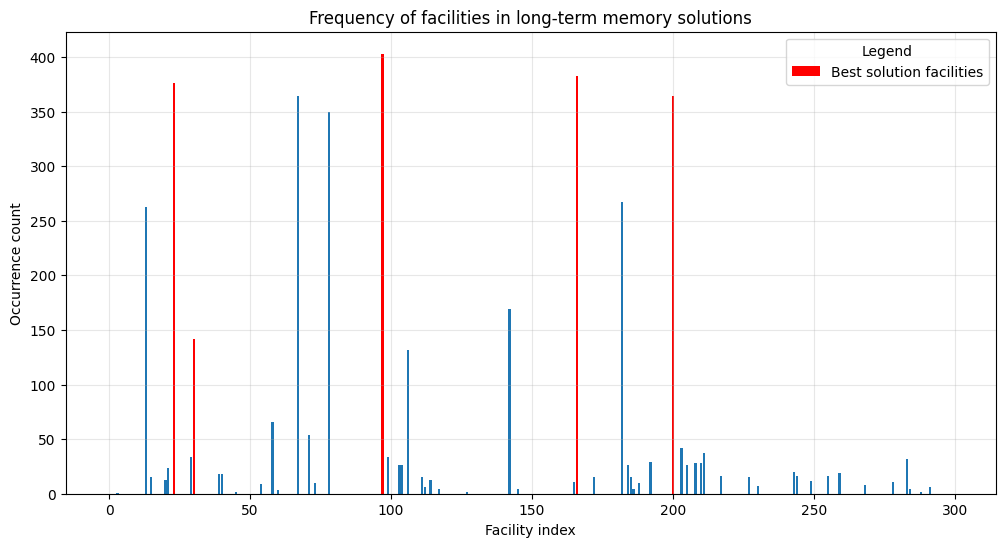

In [7]:
legend_handles = [
    Patch(facecolor='red', label='Best solution facilities'),
]


plt.figure(figsize=(12, 6))

plt.bar(range(summary['n']), facility_counts, color=colors)

plt.grid  (True, alpha=0.3)
plt.legend(
    handles=legend_handles,
    title="Legend"     ,
    loc  ="upper right",
)

plt.xlabel("Facility index"  )
plt.ylabel("Occurrence count")
plt.title ("Frequency of facilities in long-term memory solutions")

plt.show()

The following cell builds a weighted adjacency matrix capturing how frequently pairs of facilities are selected together across all long-term memory solutions. For each solution, we identify the active facilities (binary value equal to 1) and increment the corresponding pairwise entries in the matrix. The resulting symmetric matrix represents a co-occurrence graph, where edge weights indicate the number of joint selections.  

Finally, we visualize this structure as a heatmap to reveal clusters, strong associations, and frequently co-activated facilities.

In [8]:
adjacency_matrix = np.zeros(
    (
        summary['n'],
        summary['n']
    ),
    dtype=float
)

num_solutions = len(details["long_term_memory"])

for sol in details["long_term_memory"]:
    facilities       = np.array(sol["facilities"])
    facility_indices = np.where(facilities == 1  )[0]

    for i in range(len(facility_indices)):
        for j in range(i + 1, len(facility_indices)):
            idx_i = facility_indices[i]
            idx_j = facility_indices[j]

            adjacency_matrix[idx_i, idx_j] += 1
            adjacency_matrix[idx_j, idx_i] += 1

if num_solutions > 0:
    adjacency_matrix /= num_solutions

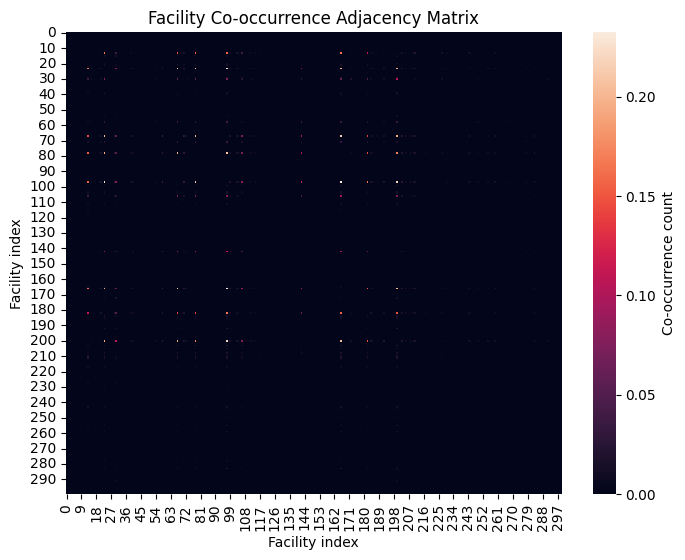

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    adjacency_matrix, cbar_kws={'label': 'Co-occurrence count'}
)

plt.title ("Facility Co-occurrence Adjacency Matrix")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

### PRINCIPAL COMPONENT ANALYSIS

Performing principal component analysis and examining the results:

In [10]:
X = matrix.astype(float)

pca   = PCA(n_components=30,
            random_state=0 ,
            svd_solver  ="full")
X_pca = pca.fit_transform(X)

explained     = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

n90 = np.searchsorted(cum_explained, 0.90) + 1

print(f"Computed components = {pca.n_components_}")
print(f"Number of components for 90% explained variance = {n90}")

Computed components = 30
Number of components for 90% explained variance = 26


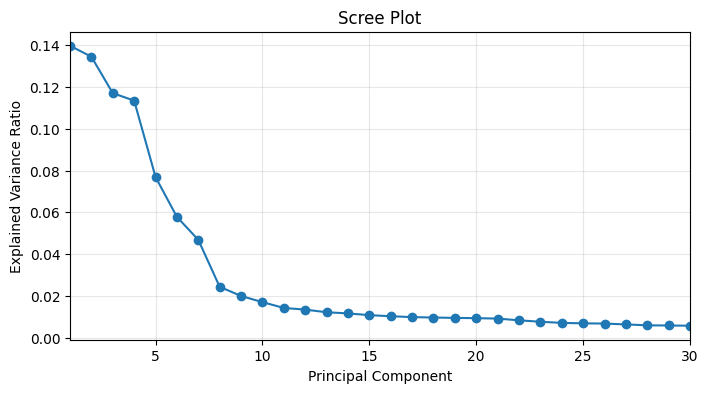

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(
    np.arange(1, len(explained) + 1), explained, marker='o'
)

plt.xlim(1, 30    )
plt.grid(alpha=0.3)

plt.xlabel("Principal Component"     )
plt.ylabel("Explained Variance Ratio")
plt.title ("Scree Plot")

plt.show()

Projection onto the first two principal components:

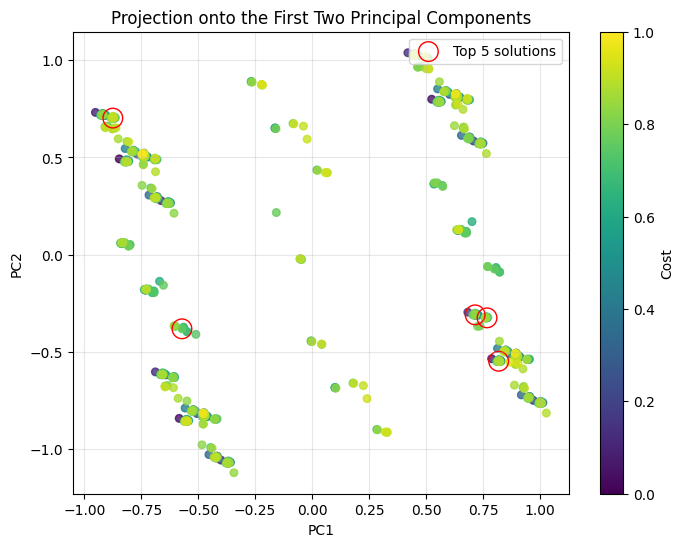

In [12]:
K = 5

best = indices[:K]


plt.figure (figsize=(8, 6))

plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=costs, cmap="viridis", s=30, alpha=0.8
)
plt.scatter(
    X_pca[best, 0], X_pca[best, 1], facecolors="none", edgecolors="red", s=200, label=f"Top {K} solutions"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title ("Projection onto the First Two Principal Components")

plt.grid  (alpha=0.3)
plt.legend(loc  ="upper right")

if costs is not None:
    plt.colorbar(label="Cost")

plt.show()

Creating heatmap with first 5 principal components:

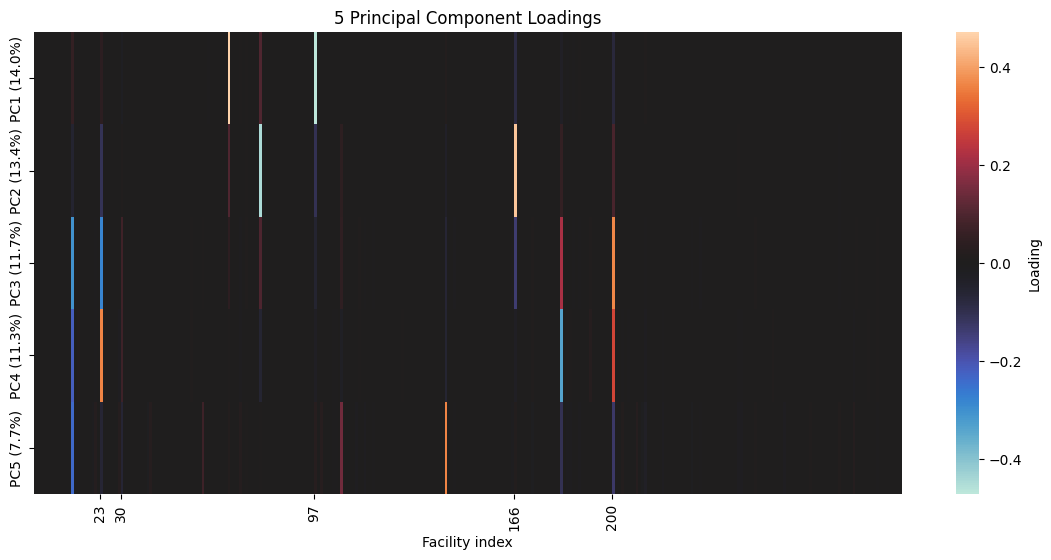

In [13]:
K_pca = 5


loadings = pca.components_[:K_pca].T * np.sqrt(pca.explained_variance_[:K_pca])

custom_xticks = sorted(best_facilities)

y_labels = [
    f"PC{i+1} ({explained[i]*100:.1f}%)"
    for i in range(K_pca)
]


fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    loadings.T, center=0, yticklabels=y_labels, cbar_kws={'label': 'Loading'}, ax=ax
)

ax.set_xlabel("Facility index")
ax.set_title ("5 Principal Component Loadings")

ax.set_xticks     (custom_xticks)
ax.set_xticklabels(custom_xticks)

plt.show()

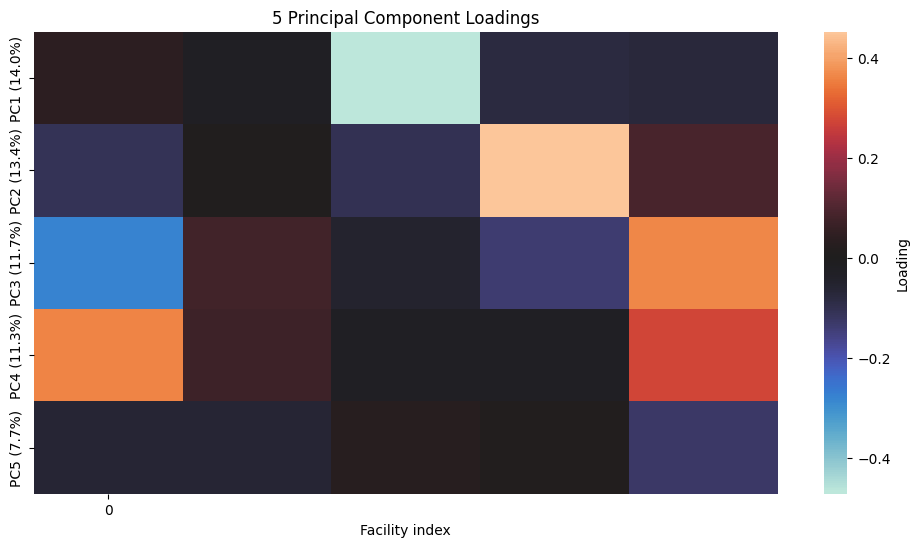

In [14]:
n_display = len(best_facilities)

mat = loadings[
    sorted(list(best_facilities))
].T

yticklabels = [
    f"PC{i+1} ({explained[i]*100:.1f}%)"
    for i in range(n_display)
]


fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    mat,
    center     =0 ,
    xticklabels=50,
    yticklabels=yticklabels         ,
    cbar_kws   ={'label': 'Loading'},
    ax=ax
)

ax.set_xlabel("Facility index")
ax.set_title (f"5 Principal Component Loadings")

plt.show()

Factor analysis:

In [15]:
n_factors = 5


fa   = FactorAnalysis(
    n_components=n_factors, random_state=0
)
X_fa = fa.fit_transform(X)


loadings_fa = fa.components_.T

loadings_df = pd.DataFrame(
    loadings_fa,
    columns=[f'Factor {i+1}' for i in range(n_factors   )],
    index  =[f'Facility {i}' for i in range(summary['n'])]
)

facility_importance = (loadings_fa ** 2).sum(axis=1)
top_facilities_fa   = np.argsort(facility_importance)[-15:][::-1]

Top facilities with best solution highlighted:

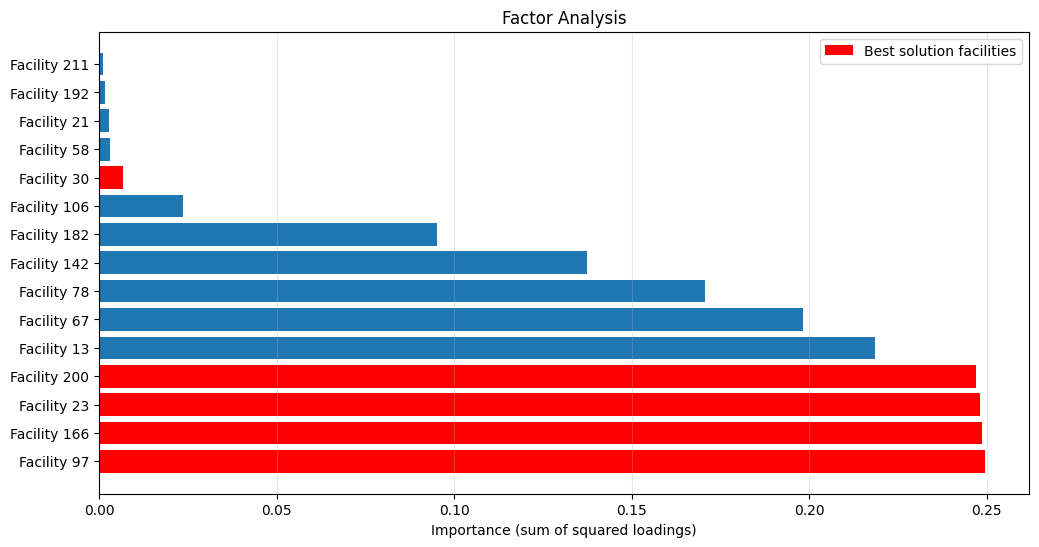

In [16]:
colors_fa = [
    'red'                     \
    if   i in best_facilities \
    else 'C0'
    for i in top_facilities_fa
]

legend_elements = [
    Patch(facecolor='red', label='Best solution facilities')
]


fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    range(len(top_facilities_fa)), facility_importance[top_facilities_fa], color=colors_fa
)

ax.set_yticks     (range(len(top_facilities_fa)))
ax.set_yticklabels([f'Facility {i}' for i in top_facilities_fa])

ax.set_xlabel('Importance (sum of squared loadings)')
ax.set_title ('Factor Analysis')

ax.grid  (True, alpha=0.3, axis='x')
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

Factor loadings heatmap:

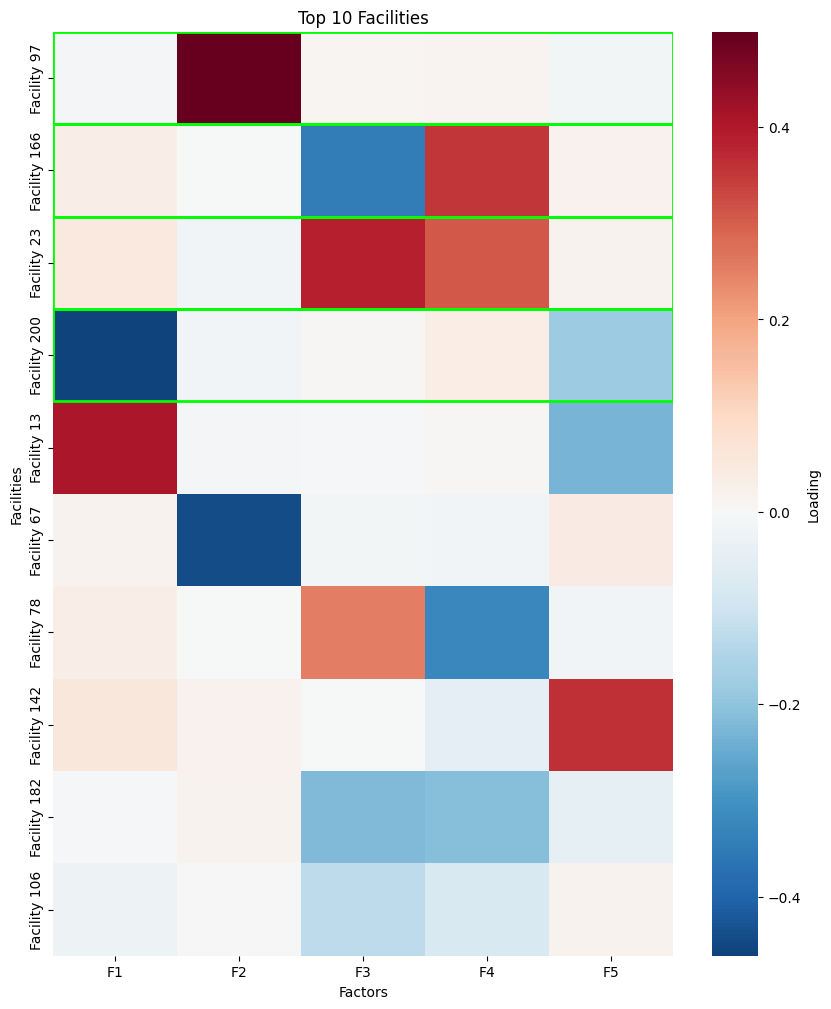

In [17]:
top_10_fa    = np.argsort(facility_importance)[-10:][::-1]
loadings_top = loadings_fa[top_10_fa, :]


fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(loadings_top,
            xticklabels=[f'F{i+1}'       for i in range(n_factors)],
            yticklabels=[f'Facility {i}' for i in top_10_fa       ],
            cbar_kws   ={'label': 'Loading'},
            cmap  ='RdBu_r',
            center=0       ,
            ax    =ax)

ax.set_xlabel('Factors'   )
ax.set_ylabel('Facilities')
ax.set_title ('Top 10 Facilities')

for i, facility in enumerate(top_10_fa):
    if facility in best_facilities:
        ax.add_patch(
            plt.Rectangle(
                (0, i), n_factors, 1, fill=False, edgecolor='lime', linewidth=2
            )
        )

plt.show()

Projection of solutions based on the first two factors:

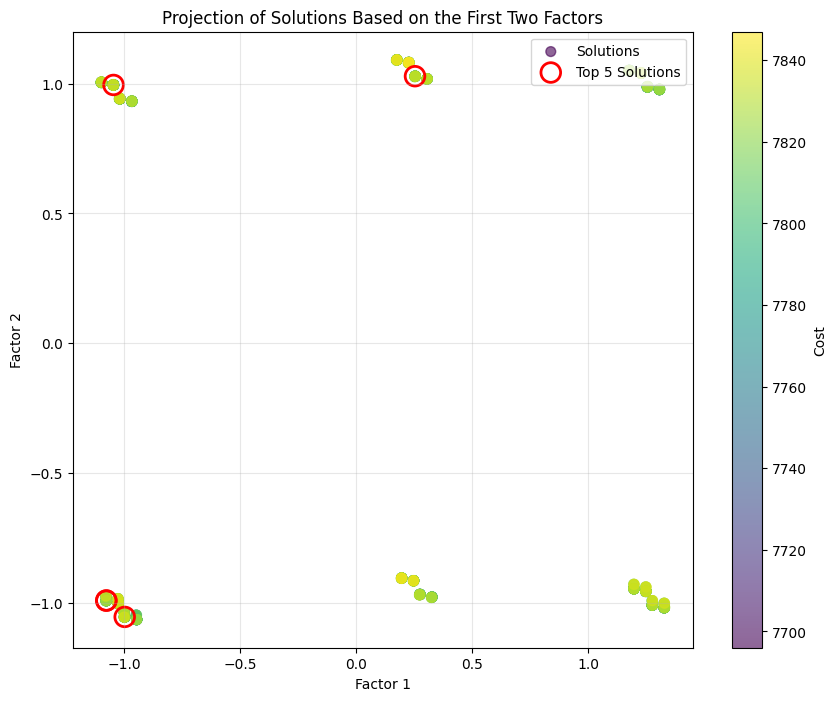

In [18]:
best_solutions_idx = indices[:5]


fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X_fa[:, 0], X_fa[:, 1], c=costs, cmap='viridis', s=50, alpha=0.6, label='Solutions'
)

ax.scatter(
    X_fa[best_solutions_idx, 0],
    X_fa[best_solutions_idx, 1],
    facecolors='none',
    edgecolors='red' ,
    s         =200,
    linewidth =2  ,
    label='Top 5 Solutions'
)

ax.set_xlabel(f'Factor 1')
ax.set_ylabel(f'Factor 2')
ax.set_title ('Projection of Solutions Based on the First Two Factors')

ax.grid  (True, alpha=0.3  )
ax.legend(loc='upper right')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cost')

plt.show()